In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
df_train = pd.read_csv(r'train_Titanic.csv')
df_test = pd.read_csv(r'test_Titanic.csv')
df_train.head()
df_train1 = df_train.drop(['Name'], axis=1)
df_train1['Sex1'] = df_train1['Sex'].map({'male': 0, 'female': 1})
df_train1['Sex2'] = df_train1['Sex'].map({'male': 1, 'female': 0})
# min_max_scaler = MinMaxScaler()
# min_max_scaler.fit(df_train1)
port_survival = df_train1.groupby('Embarked')['Survived'].agg(['mean', 'max', 'min'])
print(port_survival)
df_train1['Embarked_survived'] = df_train1.groupby('Embarked')['Survived'].transform('mean')
df_train1.head()
df_train1.drop(['Embarked'], axis=1, inplace=True)
df_train1['Fare_bin'] = pd.qcut(df_train1['Fare'], q=5, labels = [1 , 2,3,4,5],duplicates='drop')
df_train1['Fare_bin_survived'] = df_train1.groupby('Fare_bin', observed=True)['Survived'].transform('mean')
df_train1.head()

df_train1.drop(['Sex'], axis=1, inplace=True)
df_train1.head()
df_train1['Age'] = df_train1['Age'].fillna(df_train1['Age'].mean())
df_train1.isna().sum()
df_train1['Embarked_survived'] = df_train1['Embarked_survived'].fillna(df_train1['Embarked_survived'].mean())
MM = MinMaxScaler()
df_train1.head()
df_train1['Age'] = MM.fit_transform(df_train1[['Age']])
df_train1.head()
df_train1.drop(['Fare_bin' , 'PassengerId' , 'Fare'] , axis = 1 , inplace = True)
df_train1['Cabin_clean'] = df_train1['Cabin'].notna().astype(int)
df_train1.head()
ticket_counts = df_train1['Ticket'].value_counts()
df_train1['ticket_counts'] = df_train1['Ticket'].map(ticket_counts)
df_train1.head()
# print(df_train1.groupby('ticket_counts')['Survived'].mean()) 
##准备分箱 看到了票相同人数也有这个差异 分箱处理 回宿舍了 111
##把单片机和数电作业写了 就开始玩了 玩一会准备睡觉了
df_train1.head()
df_train1.drop(['Cabin'] , axis = 1 ,inplace = True)
df_train1.head()
#平滑处理
print(df_train1['ticket_counts'].value_counts())
print(df_train1.groupby('ticket_counts',observed= True)['Survived'].mean())
global_survived = df_train1['Survived'].mean()
m = 10
agg = df_train1.groupby('ticket_counts')['Survived'].agg(['count' , 'mean'])
counts = agg['count']
mean = agg['mean']
smooth = (counts * mean + m * global_survived) / (counts + m )
print(smooth)
df_train1.head()
Sex_Survived = df_train1.groupby('Sex1')['Survived'].transform('mean')
#补充对sex的特征工程 采用目标编码
df_train1['Sex_Survived'] = df_train1['Sex1'].map(Sex_Survived)
df_train1.head()
#补充对Cabin
Cabin_Survived = df_train1.groupby('Cabin_clean')['Survived'].transform('mean')
df_train1['Cabin_Survived'] = df_train1['Cabin_clean'].map(Cabin_Survived)
df_train1.head()

              mean  max  min
Embarked                    
C         0.553571    1    0
Q         0.389610    1    0
S         0.336957    1    0
ticket_counts
1    547
2    188
3     63
4     44
7     21
6     18
5     10
Name: count, dtype: int64
ticket_counts
1    0.297989
2    0.574468
3    0.698413
4    0.500000
5    0.000000
6    0.000000
7    0.238095
Name: Survived, dtype: float64
ticket_counts
1    0.299530
2    0.564840
3    0.655320
4    0.478489
5    0.191919
6    0.137085
7    0.285109
dtype: float64


,Survived,Pclass,Age,SibSp,Parch,Ticket,Sex1,Sex2,Embarked_survived,Fare_bin_survived,Cabin_clean,ticket_counts,Sex_Survived,Cabin_Survived
0,0,3,0.271174,1,0,A/5 21171,0,1,0.336957,0.217877,0,1,0.188908,0.299854
1,1,1,0.472229,1,0,PC 17599,1,0,0.553571,0.642045,1,1,0.742038,0.666667
2,1,3,0.321438,0,0,STON/O2. 3101282,1,0,0.336957,0.201087,0,1,0.742038,0.299854
3,1,1,0.434531,1,0,113803,1,0,0.336957,0.642045,1,2,0.742038,0.666667
4,0,3,0.434531,0,0,373450,0,1,0.336957,0.201087,0,1,0.188908,0.299854


In [54]:
# display(df_train1)
df_train1['ticket_counts_smooth'] = df_train1['ticket_counts'].map(smooth)
df_train1.head()
#对兄弟姐妹进行处理
SibSp_counts = df_train1['SibSp'].value_counts()
df_train1['SibSp_counts'] = df_train1['SibSp'].map(SibSp_counts)
df_train1.head()
df_train1.groupby('SibSp_counts')['Survived'].mean()
df_train1['SibSp_Survived'] = df_train1.groupby('SibSp')['Survived'].transform('mean')
summary = df_train1.groupby('SibSp')['Survived'].agg(['count' , 'mean'])
summary.columns = ['组内总人数', '生还率']
print(summary)
#对姐妹平滑处理
agg_SibSp = df_train1.groupby('SibSp')['Survived'].agg(['count' , 'mean'])
counts_SibSp = agg_SibSp['count']
means_SibSp = agg_SibSp['mean']
smooth_SibSp = (counts_SibSp * means_SibSp + m * global_survived) / (counts_SibSp + m)
df_train1['SibSp_Survived_smooth'] = df_train1['SibSp'].map(smooth_SibSp)
df_train1.head()
#如法炮制对Pclass
Pclass_Survived = df_train1.groupby('Pclass')['Survived'].transform('mean')
df_train1['Pclass_Survived'] = Pclass_Survived
df_train1.head()
#对Parch 除了平滑处理是否还有别的方式？
print(df_train1.groupby('Parch')['Survived'].mean())
print(df_train1['Parch'].value_counts())
agg_Parch = df_train1.groupby('Parch')['Survived'].agg(['count' , 'mean'])
counts_Parch = agg_Parch['count']
means_Parch = agg_Parch['mean']
Parch_Survived_Smooth = (counts_Parch * means_Parch + m * global_survived) / (counts_Parch + m)
print(Parch_Survived_Smooth)
df_train1['Parch_Survived_Smooth'] = df_train1['Parch'].map(Parch_Survived_Smooth)
df_train1.head()
#新建特征 家人 家人们加油
df_train1['Family_Size'] = df_train1['SibSp'] + df_train1['Parch'] + 1
family_agg = df_train1.groupby('Family_Size')['Survived'].agg(['count' , 'mean'])
counts_Family_Size = family_agg['count']
means_Family_Size = family_agg['mean']
Family_Size_Survived_Smooth = (counts_Family_Size * means_Family_Size + m * global_survived) / (counts_Family_Size + m)
df_train1['Family_Size_Survived_Smooth'] = df_train1['Family_Size'].map(Family_Size_Survived_Smooth)
df_test['Family_Size'] = df_test['SibSp'] + df_test['Parch'] + 1
df_train1.head()


       组内总人数       生还率
SibSp                 
0        608  0.345395
1        209  0.535885
2         28  0.464286
3         16  0.250000
4         18  0.166667
5          5  0.000000
8          7  0.000000
Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Parch
0    0.344242
1    0.537800
2    0.487093
3    0.455892
4    0.274170
5    0.322559
6    0.348944
dtype: float64


,Survived,Pclass,Age,SibSp,Parch,Ticket,Sex1,Sex2,Embarked_survived,Fare_bin_survived,...,Sex_Survived,Cabin_Survived,ticket_counts_smooth,SibSp_counts,SibSp_Survived,SibSp_Survived_smooth,Pclass_Survived,Parch_Survived_Smooth,Family_Size,Family_Size_Survived_Smooth
0,0,3,0.271174,1,0,A/5 21171,0,1,0.336957,0.217877,...,0.188908,0.299854,0.29953,209,0.535885,0.528942,0.242363,0.344242,2,0.542915
1,1,1,0.472229,1,0,PC 17599,1,0,0.553571,0.642045,...,0.742038,0.666667,0.29953,209,0.535885,0.528942,0.629630,0.344242,2,0.542915
2,1,3,0.321438,0,0,STON/O2. 3101282,1,0,0.336957,0.201087,...,0.742038,0.299854,0.29953,608,0.345395,0.346017,0.242363,0.344242,1,0.305006
3,1,1,0.434531,1,0,113803,1,0,0.336957,0.642045,...,0.742038,0.666667,0.56484,209,0.535885,0.528942,0.629630,0.344242,2,0.542915
4,0,3,0.434531,0,0,373450,0,1,0.336957,0.201087,...,0.188908,0.299854,0.29953,608,0.345395,0.346017,0.242363,0.344242,1,0.305006


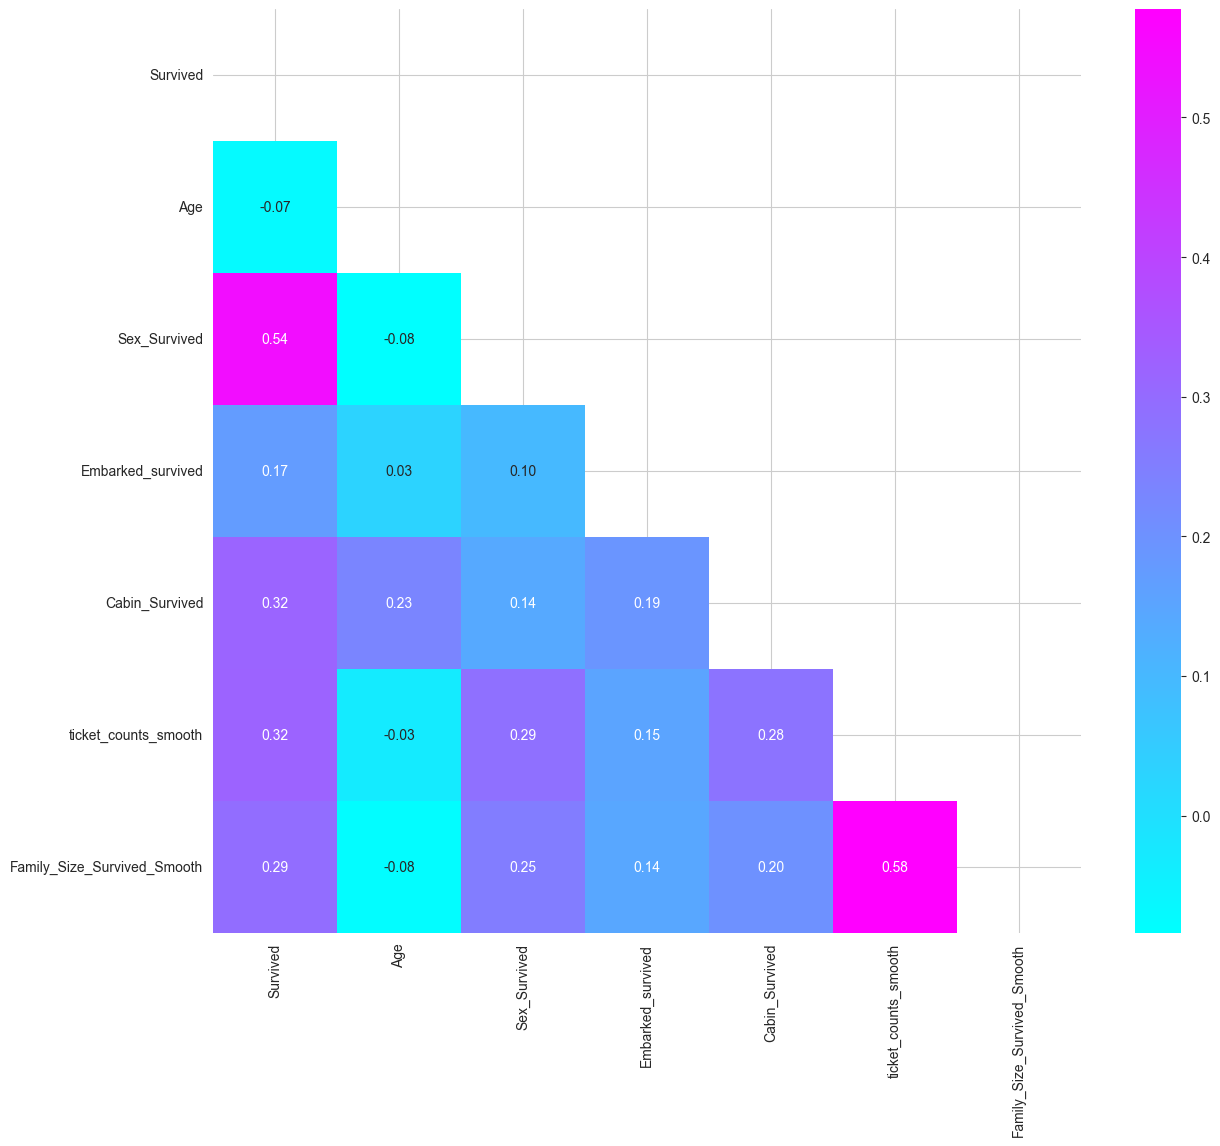

{'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
0.8044692737430168
0.8117977528089888
0.8044692737430168
【测试集防爆检查】缺失值总数:
 Age                            0
Sex_Survived                   0
Embarked_survived              0
Cabin_Survived                 0
ticket_counts_smooth           0
Family_Size_Survived_Smooth    0
dtype: int64

【收网成功】文件已生成：lemon_sheep_V13_Submission.csv，准备提交 Kaggle！


In [56]:
#准备收网 去除冗余特征
final_features = [
    'Survived'
    ,'Age'
    ,'Sex_Survived'
    ,'Embarked_survived'
    ,'Cabin_Survived'
    ,'ticket_counts_smooth'
    ,'Family_Size_Survived_Smooth'
]
df_train2 = df_train1[final_features]
df_train2.head()
#热力图展示
corr_matrix = df_train2.corr()
mask = np.triu(np.ones_like(corr_matrix , dtype = bool))
fig , ax = plt.subplots(figsize = (14,12))
sns.heatmap(corr_matrix, mask = mask, cmap = 'cool' , annot= True , fmt = '.2f')
plt.show() 
#机器学习的内容了
X = df_train2.drop('Survived', axis = 1)
Y = df_train2['Survived']
train_x , test_x , train_y , test_y = train_test_split(X , Y , test_size = 0.2, random_state = 42)
robot = KNeighborsClassifier()
param_grid = {'n_neighbors': range(5,30)
    , 'weights': ['uniform', 'distance']
    , 'metric' : ['euclidean', 'manhattan']}
grid_Search = GridSearchCV(estimator = robot, param_grid = param_grid , cv =10 , n_jobs = -1)
grid_Search.fit(train_x, train_y)
print(grid_Search.best_params_)
test_score = grid_Search.score(test_x, test_y)
print(test_score)
# 开启 Test 测试集产线 (完全复用 Train 的标定字典)

# 1. 提取训练集里的“查找字典” (从最原始的 df_train 提取最安全)
sex_dict = df_train.groupby('Sex')['Survived'].mean()
embarked_dict = df_train.groupby('Embarked')['Survived'].mean()
cabin_dict = df_train1.groupby('Cabin_clean')['Survived'].mean() # 船舱有无的生还率
# 2. 映射测试集基础特征 (查表替换)
df_test['Sex_Survived'] = df_test['Sex'].map(sex_dict)
df_test['Embarked_survived'] = df_test['Embarked'].map(embarked_dict)
# 填充 Embarked 缺失值（用训练集的 Embarked 均值兜底）
train_embarked_mean = df_train1['Embarked_survived'].mean()
df_test['Embarked_survived'] = df_test['Embarked_survived'].fillna(train_embarked_mean)
# 测试集的 Cabin 转换为 0/1，然后查表
df_test['Cabin_clean'] = df_test['Cabin'].notna().astype(int)
df_test['Cabin_Survived'] = df_test['Cabin_clean'].map(cabin_dict)
# 3. 映射年龄 (必须用 train 的均值填补，且只用 transform！)
train_age_mean = df_train['Age'].mean() 
df_test['Age'] = df_test['Age'].fillna(train_age_mean)
# 注意：这里绝对不能写 fit_transform！只能用已经 fit 好的 MM 尺子去量
df_test['Age'] = MM.transform(df_test[['Age']]) 
# 4. 映射 Ticket 
# 逻辑：如果测试集的票在训练集没出现过，fillna(1) 代表算作 1 个人
df_test['ticket_counts'] = df_test['Ticket'].map(ticket_counts).fillna(1)
# 然后去查我们算好的 smooth 字典，查不到的用全局生还率兜底
df_test['ticket_counts_smooth'] = df_test['ticket_counts'].map(smooth).fillna(global_survived)
# 5. 映射家庭规模 (SibSp 和 Parch)
df_test['Family_Size_Survived_Smooth'] = df_test['Family_Size'].map(Family_Size_Survived_Smooth).fillna(global_survived)
# 6. 组装测试集终极特征矩阵 (必须与 df_train2 的列名和顺序 100% 对齐！)
test_features = [
    'Age',
    'Sex_Survived',
    'Embarked_survived',
    'Cabin_Survived',
    'ticket_counts_smooth',
    'Family_Size_Survived_Smooth'
]

# 剔除掉 Survived 列，因为 X 训练集里也没有 Survived
df_test2 = df_test[test_features]
# 7. 终极预测与导出 
final_predictions = grid_Search.predict(df_test2)

submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": final_predictions
})
print(grid_Search.score(train_x, train_y))
print(grid_Search.score(test_x, test_y))
submission.to_csv('lemon_sheep_V13_Submission.csv', index=False)
print("【测试集防爆检查】缺失值总数:\n", df_test2.isna().sum())
print("\n【收网成功】文件已生成：lemon_sheep_V13_Submission.csv，准备提交 Kaggle！")